# Example to use the Sherpa minimizer plugin with a JeSeT model

In this tutorial we show how to import a jetset model into sherpa, and finally we perform a model fitting.
To run this plugin you have to install Sherpa: https://sherpa.readthedocs.io/en/latest/install.html

In [3]:
import jetset
print('tested with',jetset.__version__)

tested with 1.4.0rc0


In [4]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pylab as plt
import jetset
from jetset.test_data_helper import  test_SEDs
from jetset.data_loader import ObsData,Data
from jetset.plot_sedfit import PlotSED
from jetset.test_data_helper import  test_SEDs

In [5]:
test_SEDs

['/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_3C345.ecsv',
 '/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_MW_Mrk421_EBL_DEABS.ecsv',
 '/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_MW_Mrk501_EBL_ABS.ecsv',
 '/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_MW_Mrk501_EBL_DEABS.ecsv']

## Loading data



In [6]:
print(test_SEDs[2])
data=Data.from_file(test_SEDs[2])


/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_MW_Mrk501_EBL_ABS.ecsv



***  binning data  ***
---> N bins= 88
---> bin_width= 0.2



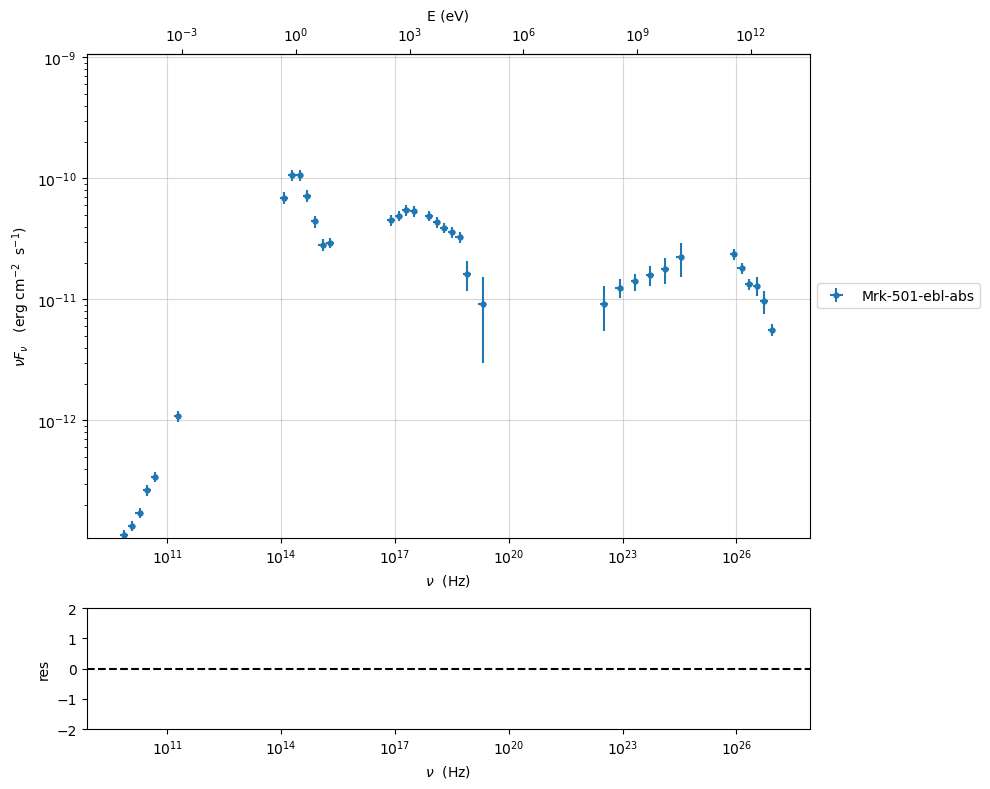

In [7]:
%matplotlib inline
sed_data=ObsData(data_table=data)
sed_data.group_data(bin_width=0.2)

sed_data.add_systematics(0.1,[10.**6,10.**29])
p=sed_data.plot_sed()

In [8]:
sed_data.save('Mrk_501.pkl')

## phenomenological model constraining

### spectral indices


*** evaluating spectral indices for data ***



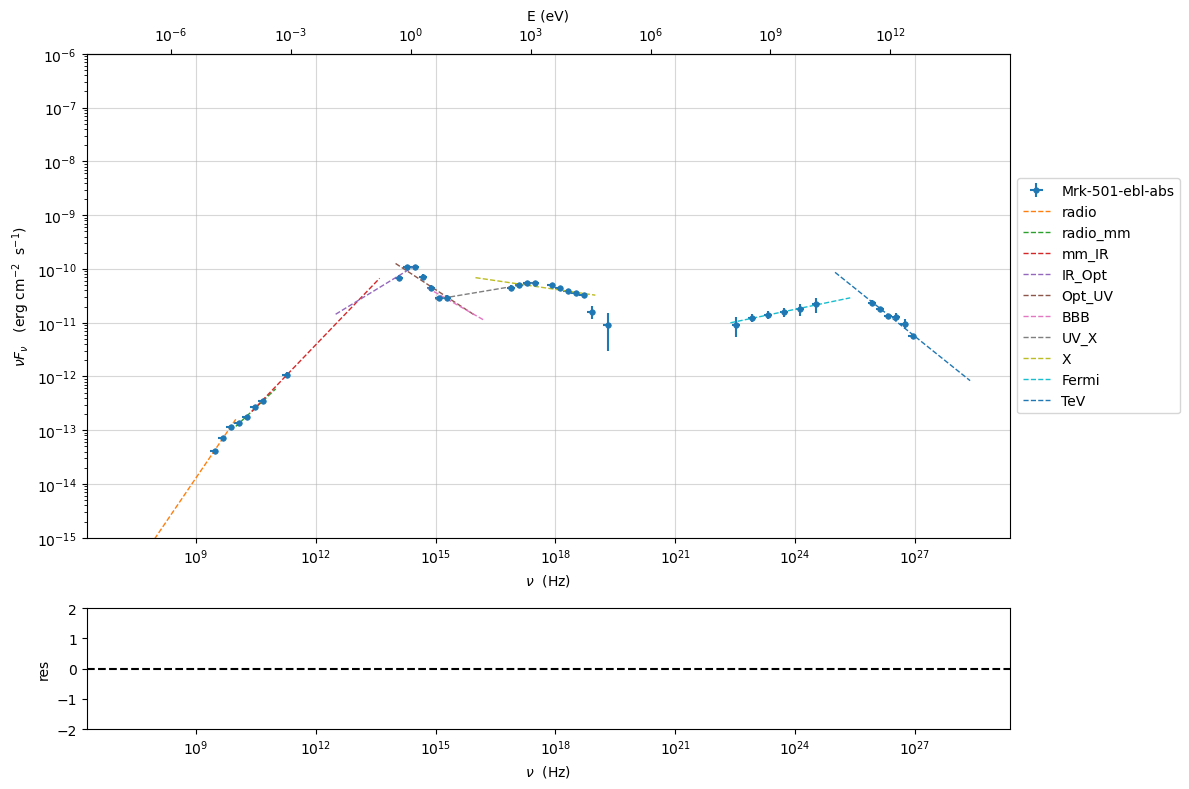

In [9]:
from jetset.sed_shaper import  SEDShape
my_shape=SEDShape(sed_data)
my_shape.eval_indices(minimizer='lsb',silent=True)
p=my_shape.plot_indices()
p.setlim(y_min=1E-15,y_max=1E-6)

### sed shaper

In [10]:
mm,best_fit=my_shape.sync_fit(check_host_gal_template=True,
                  Ep_start=None,
                  minimizer='lsb',
                  silent=True,
                  fit_range=[10.,21.])


*** Log-Polynomial fitting of the synchrotron component ***
---> first blind fit run,  fit range: [10.0, 21.0]
---> class:  HSP

---> class:  HSP




model name,name,val,bestfit val,err +,err -,start val,fit range min,fit range max,frozen
LogCubic,b,-5.589204e-02,-5.589204e-02,6.234447e-03,--,-5.237376e-02,-1.000000e+01,0.000000e+00,False
LogCubic,c,-3.292704e-04,-3.292704e-04,8.967926e-04,--,7.639964e-03,-1.000000e+01,1.000000e+01,False
LogCubic,Ep,1.698160e+01,1.698160e+01,8.582826e-02,--,1.556163e+01,0.000000e+00,3.000000e+01,False
LogCubic,Sp,-1.030620e+01,-1.030620e+01,1.607947e-02,--,-1.019011e+01,-3.000000e+01,0.000000e+00,False
host_galaxy,nuFnu_p_host,-9.972939e+00,-9.972939e+00,3.177493e-02,--,-1.019011e+01,-1.219011e+01,-8.190114e+00,False
host_galaxy,nu_scale,-2.290459e-03,-2.290459e-03,1.811351e-03,--,0.000000e+00,-2.908697e-03,2.908697e-03,False


---> sync       nu_p=+1.698160e+01 (err=+8.582826e-02)  nuFnu_p=-1.030620e+01 (err=+1.607947e-02) curv.=-5.589204e-02 (err=+6.234447e-03)




*** Log-Polynomial fitting of the IC component ***
---> fit range: [23.0, 29.0]
---> LogCubic fit




model name,name,val,bestfit val,err +,err -,start val,fit range min,fit range max,frozen
LogCubic,b,-1.627265e-01,-1.627265e-01,2.483991e-02,--,-1.000000e+00,-1.000000e+01,0.000000e+00,False
LogCubic,c,-4.569970e-02,-4.569970e-02,1.984551e-02,--,-1.000000e+00,-1.000000e+01,1.000000e+01,False
LogCubic,Ep,2.526444e+01,2.526444e+01,1.736457e-01,--,2.531190e+01,0.000000e+00,3.000000e+01,False
LogCubic,Sp,-1.057790e+01,-1.057790e+01,4.914805e-02,--,-1.000000e+01,-3.000000e+01,0.000000e+00,False


---> IC         nu_p=+2.526444e+01 (err=+1.736457e-01)  nuFnu_p=-1.057790e+01 (err=+4.914805e-02) curv.=-1.627265e-01 (err=+2.483991e-02)



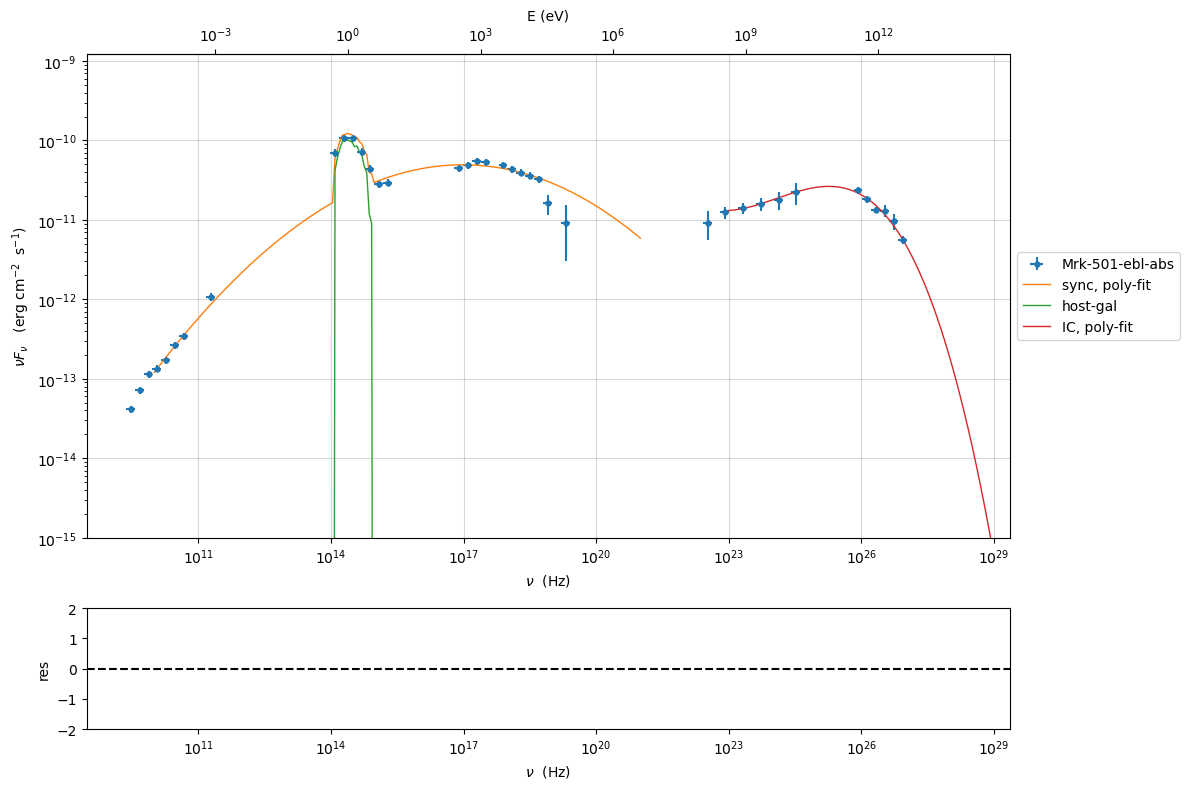

In [11]:
my_shape.IC_fit(fit_range=[23.,29.],minimizer='minuit',silent=True)
p=my_shape.plot_shape_fit()
p.setlim(y_min=1E-15)

### Model constraining

In this step we are not fitting the model, we are just obtaining the phenomenological `pre_fit` model, that will be fitted in using minuit ore least-square bound, as shown below

In [12]:
from jetset.obs_constrain import ObsConstrain
from jetset.model_manager import  FitModel
sed_obspar=ObsConstrain(beaming=25,
                        B_range=[0.001,0.1],
                        distr_e='lppl',
                        t_var_sec=3*86400,
                        nu_cut_IR=1E12,
                        SEDShape=my_shape)


prefit_jet=sed_obspar.constrain_SSC_model(electron_distribution_log_values=False,silent=True)
prefit_jet.save_model('prefit_jet.pkl')


***  constrains parameters from observable ***



/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/obs_constrain.py:1514: RankWarning: Polyfit may be poorly conditioned
  p=polyfit(nu_p_IC_model_log,B_grid_log,2)


model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
jet_leptonic,R,region_size,cm,1.216622e+16,1.000000e+03,1.000000e+30,False,False
jet_leptonic,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
jet_leptonic,B,magnetic_field,gauss,5.050000e-02,0.000000e+00,--,False,False
jet_leptonic,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True
jet_leptonic,beam_obj,beaming,,2.500000e+01,1.000000e-04,--,False,False
jet_leptonic,z_cosm,redshift,,3.360000e-02,0.000000e+00,--,False,False
jet_leptonic,gmin,low-energy-cut-off,lorentz-factor*,4.703917e+02,1.000000e+00,1.000000e+09,False,False
jet_leptonic,gmax,high-energy-cut-off,lorentz-factor*,2.121873e+06,1.000000e+00,1.000000e+15,False,False
jet_leptonic,N,emitters_density,1 / cm3,5.583988e+00,0.000000e+00,--,False,False
jet_leptonic,gamma0_log_parab,turn-over-energy,lorentz-factor*,6.673207e+03,1.000000e+00,1.000000e+09,False,False


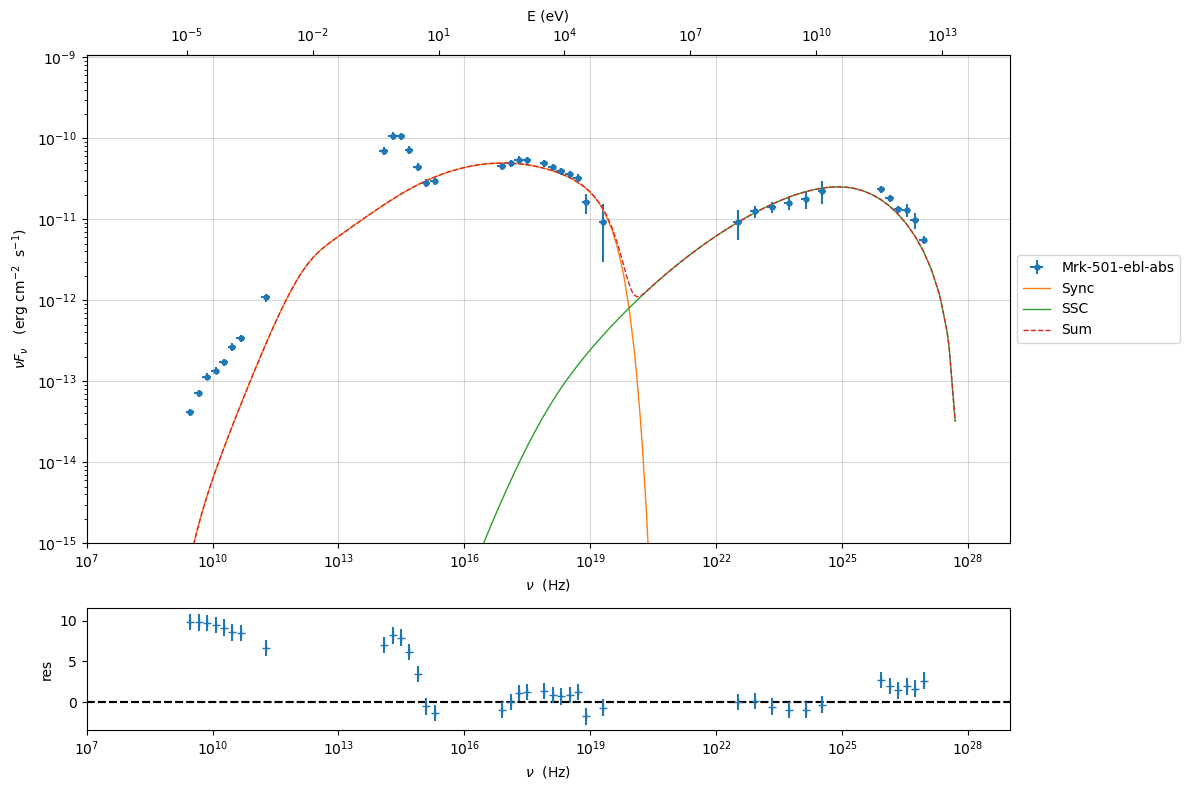

In [13]:
pl=prefit_jet.plot_model(sed_data=sed_data)
pl.add_model_residual_plot(prefit_jet,sed_data)
pl.setlim(y_min=1E-15,x_min=1E7,x_max=1E29)

## Model fitting with Sherpa


In [14]:
from jetset.template_2Dmodel import EBLAbsorptionTemplate
ebl_franceschini=EBLAbsorptionTemplate.from_name('Franceschini_2008')

In [15]:
from jetset.jet_model import Jet
prefit_jet=Jet.load_model('prefit_jet.pkl')


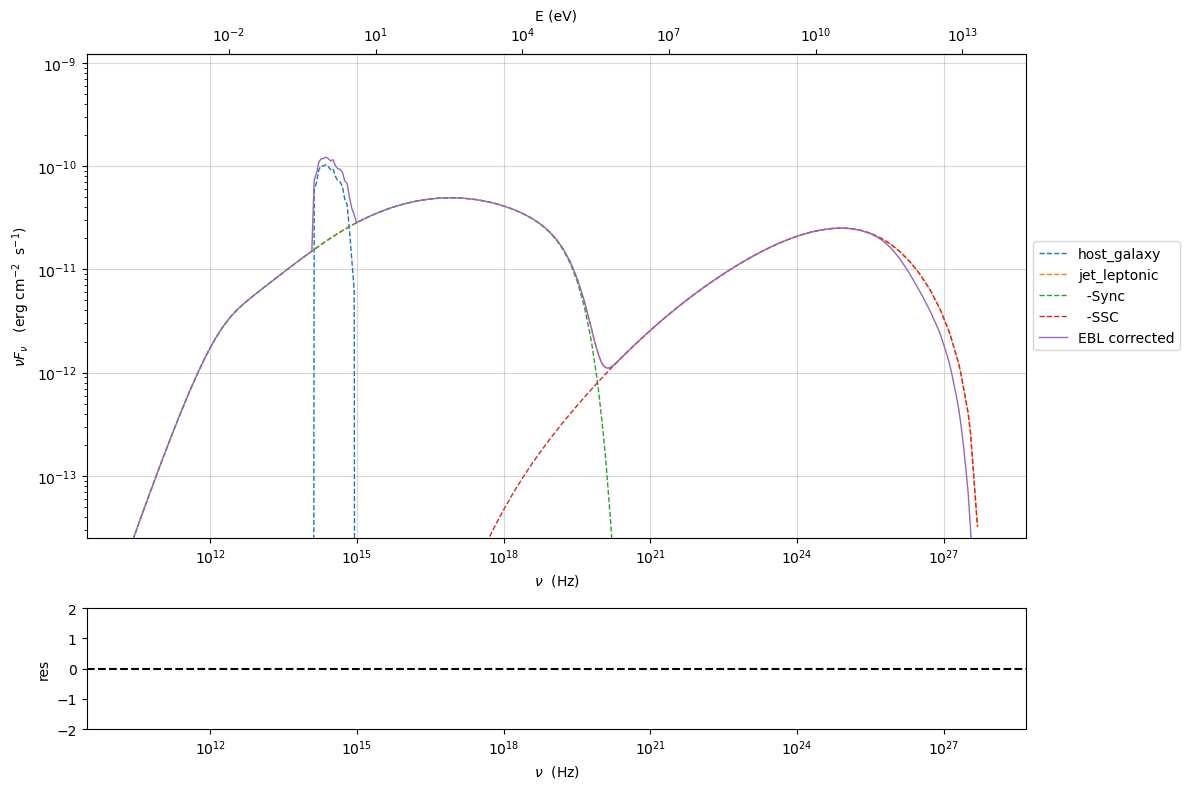

In [16]:
composite_model=FitModel(nu_size=500,name='EBL corrected',template=my_shape.host_gal)
composite_model.add_component(prefit_jet)
composite_model.add_component(ebl_franceschini)
composite_model.link_par(par_name='z_cosm', from_model='Franceschini_2008', to_model='jet_leptonic')
composite_model.composite_expr='(jet_leptonic+host_galaxy)*Franceschini_2008'
composite_model.eval()
composite_model.plot_model()

In [17]:
composite_model.freeze('jet_leptonic','z_cosm')
composite_model.freeze('jet_leptonic','R_H')
composite_model.jet_leptonic.parameters.beam_obj.fit_range=[5., 50.]
composite_model.jet_leptonic.parameters.R.fit_range=[10**15.5,10**17.5]
composite_model.jet_leptonic.parameters.gmax.fit_range=[1E5,1E7]
composite_model.host_galaxy.parameters.nuFnu_p_host.frozen=False
composite_model.host_galaxy.parameters.nu_scale.frozen=True

In [18]:
from jetset.minimizer import ModelMinimizer
composite_model.jet_leptonic.parameters.z_cosm.frozen=True

model_minimizer_lsb=ModelMinimizer('sherpa')
best_fit=model_minimizer_lsb.fit(composite_model,sed_data,1E11,1E29,fitname='SSC-best-fit-sherpa',repeat=1)

ImportError: to use sherpa plugin you need to install sherpa: https://sherpa.readthedocs.io/en/latest/install.html

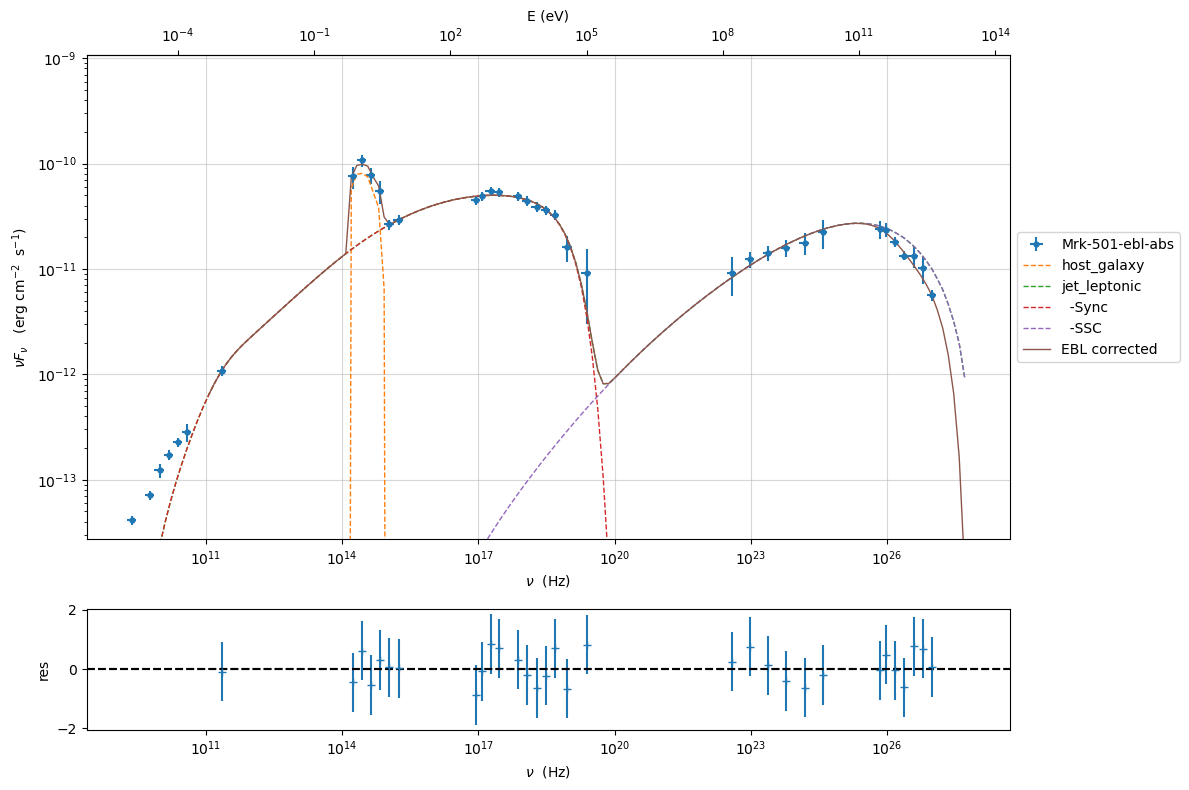

In [ ]:
composite_model.set_nu_grid(1E6,1E30,200)
composite_model.eval()
p=composite_model.plot_model(sed_data=sed_data)

Using the ``sherpa_fitter`` you can access all the sherpa fetarues https://sherpa.readthedocs.io/en/latest/fit/index.html

In [ ]:
model_minimizer_lsb.minimizer.sherpa_fitter.est_errors()


Parameter,Best-fit value,Lower Bound,Upper Bound
EBL corrected.nuFnu_p_host,-10.0606,-0.0509997,0.0509997
EBL corrected.gmin,255.657,-----,-----
EBL corrected.gmax,2.07799e+06,-----,-----
EBL corrected.N,8.51252,-2.52709,2.52709
EBL corrected.gamma0_log_parab,5659.11,-1064.69,1064.69
EBL corrected.s,2.20821,-0.0248637,0.0248637
EBL corrected.r,0.214529,-0.0197456,0.0197456
EBL corrected.R_sh,1.44914e+16,-4.11409e+15,4.11409e+15
EBL corrected.B,0.0117539,-----,-----
EBL corrected.beam_obj,43.7716,-4.81248,4.81248


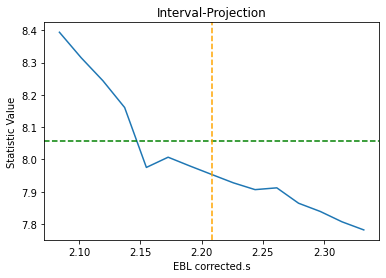

In [ ]:
from sherpa.plot import IntervalProjection
iproj = IntervalProjection()
iproj.prepare(fac=5, nloop=15)
iproj.calc(model_minimizer_lsb.minimizer.sherpa_fitter, model_minimizer_lsb.minimizer._sherpa_model.s)
iproj.plot()